In [652]:
print("Kernel is working")


Kernel is working


In [653]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries imported successfully")


All libraries imported successfully


In [654]:
df = pd.read_csv("cleaned_hotel_booking_new.csv")
df.head()


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,no_of_previous_cancellations,no_of_previous_bookings_not_cancelled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_guests,month_name,arrival_date_with_month,total_amount
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,0,0,65,0,Not_Cancelled,3,2,October,43010.0,195
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,0,0,107,1,Not_Cancelled,5,2,November,43410.0,535
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,0,0,60,0,Cancelled,3,1,February,43159.0,180
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,0,0,100,0,Cancelled,2,2,May,43240.0,200
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,0,0,94,0,Cancelled,2,2,April,43201.0,188


In [655]:
df.shape


(36275, 24)

In [656]:
df.columns


Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_cancelled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'total_nights', 'total_guests', 'month_name', 'arrival_date_with_month',
       'total_amount'],
      dtype='object')

In [657]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Booking_ID                             36275 non-null  object 
 1   no_of_adults                           36275 non-null  int64  
 2   no_of_children                         36275 non-null  int64  
 3   no_of_weekend_nights                   36275 non-null  int64  
 4   no_of_week_nights                      36275 non-null  int64  
 5   type_of_meal_plan                      36275 non-null  object 
 6   required_car_parking_space             36275 non-null  int64  
 7   room_type_reserved                     36275 non-null  object 
 8   lead_time                              36275 non-null  int64  
 9   arrival_year                           36275 non-null  int64  
 10  arrival_month                          36275 non-null  int64  
 11  ar

In [658]:
df.isnull().sum()


Booking_ID                                0
no_of_adults                              0
no_of_children                            0
no_of_weekend_nights                      0
no_of_week_nights                         0
type_of_meal_plan                         0
required_car_parking_space                0
room_type_reserved                        0
lead_time                                 0
arrival_year                              0
arrival_month                             0
arrival_date                              0
market_segment_type                       0
repeated_guest                            0
no_of_previous_cancellations              0
no_of_previous_bookings_not_cancelled     0
avg_price_per_room                        0
no_of_special_requests                    0
booking_status                            0
total_nights                              0
total_guests                              0
month_name                                0
arrival_date_with_month         

In [659]:
df.drop(columns=['arrival_date_with_month'], inplace=True)


In [660]:
df.isnull().sum()

Booking_ID                               0
no_of_adults                             0
no_of_children                           0
no_of_weekend_nights                     0
no_of_week_nights                        0
type_of_meal_plan                        0
required_car_parking_space               0
room_type_reserved                       0
lead_time                                0
arrival_year                             0
arrival_month                            0
arrival_date                             0
market_segment_type                      0
repeated_guest                           0
no_of_previous_cancellations             0
no_of_previous_bookings_not_cancelled    0
avg_price_per_room                       0
no_of_special_requests                   0
booking_status                           0
total_nights                             0
total_guests                             0
month_name                               0
total_amount                             0
dtype: int6

In [661]:
df.shape
df.head()


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_cancelled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_guests,month_name,total_amount
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,0,0,0,65,0,Not_Cancelled,3,2,October,195
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,0,0,0,107,1,Not_Cancelled,5,2,November,535
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,0,0,0,60,0,Cancelled,3,1,February,180
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,0,0,0,100,0,Cancelled,2,2,May,200
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,0,0,0,94,0,Cancelled,2,2,April,188


In [662]:
df['booking_status'].value_counts(normalize=True) * 100


booking_status
Not_Cancelled    67.236389
Cancelled        32.763611
Name: proportion, dtype: float64

In [663]:
df.groupby('booking_status')['avg_price_per_room'].mean()


booking_status
Cancelled        110.570467
Not_Cancelled     99.926363
Name: avg_price_per_room, dtype: float64

In [664]:
df.groupby('booking_status')['lead_time'].mean()


booking_status
Cancelled        139.215482
Not_Cancelled     58.927224
Name: lead_time, dtype: float64

In [665]:
pd.crosstab(df['repeated_guest'], df['booking_status'], normalize='index') * 100


booking_status,Cancelled,Not_Cancelled
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


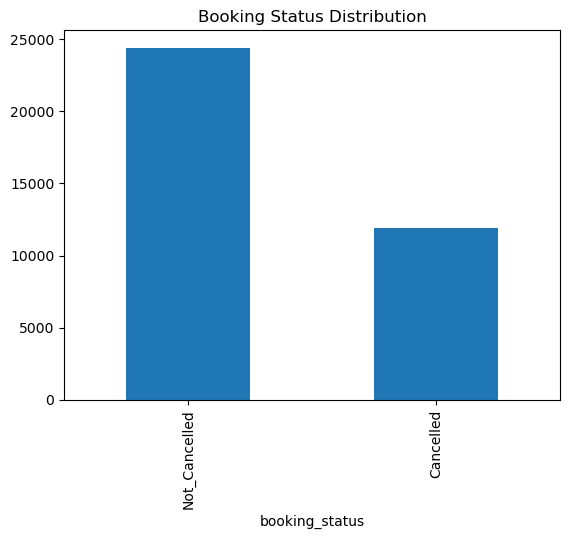

In [666]:
df['booking_status'].value_counts().plot(kind='bar')
plt.title("Booking Status Distribution")
plt.show()


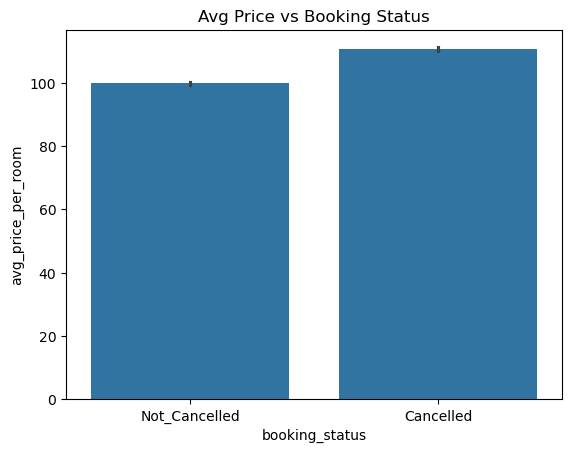

In [667]:
import seaborn as sns

sns.barplot(x='booking_status', y='avg_price_per_room', data=df)
plt.title("Avg Price vs Booking Status")
plt.show()


In [ ]:
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title("Lead Time vs Booking Status")
plt.show()


In [669]:
df.to_csv("final_hotel_booking_cleaned.csv", index=False)


In [670]:
import pandas as pd

# Load the cleaned CSV
df = pd.read_csv("final_hotel_booking_cleaned.csv")

# See first 5 rows
print(df.head())

# Check unique values in booking_status
print(df['booking_status'].unique())

# Check missing values
print(df[['lead_time','avg_price_per_room','booking_status']].isna().sum())


  Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0   INN00001             2               0                     1   
1   INN00002             2               0                     2   
2   INN00003             1               0                     2   
3   INN00004             2               0                     0   
4   INN00005             2               0                     1   

   no_of_week_nights type_of_meal_plan  required_car_parking_space  \
0                  2       Meal Plan 1                           0   
1                  3      Not Selected                           0   
2                  1       Meal Plan 1                           0   
3                  2       Meal Plan 1                           0   
4                  1      Not Selected                           0   

  room_type_reserved  lead_time  arrival_year  ...  repeated_guest  \
0        Room_Type 1        224          2017  ...               0   
1        Room_Type 1          

In [671]:
# Encode booking_status
df['booking_status_encoded'] = df['booking_status'].map({
    'Not_Cancelled': 0,
    'Cancelled': 1
})

# Check that both classes exist
print(df['booking_status_encoded'].value_counts())


booking_status_encoded
0    24390
1    11885
Name: count, dtype: int64


In [672]:
# Features (X) and target (y)
X = df[['lead_time', 'avg_price_per_room']]  # only numeric features
y = df['booking_status_encoded']             # target


In [673]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [674]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [675]:
y_pred = model.predict(X_test)


In [676]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7622329427980703

Confusion Matrix:
 [[4424  415]
 [1310 1106]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.84      4839
           1       0.73      0.46      0.56      2416

    accuracy                           0.76      7255
   macro avg       0.75      0.69      0.70      7255
weighted avg       0.76      0.76      0.75      7255



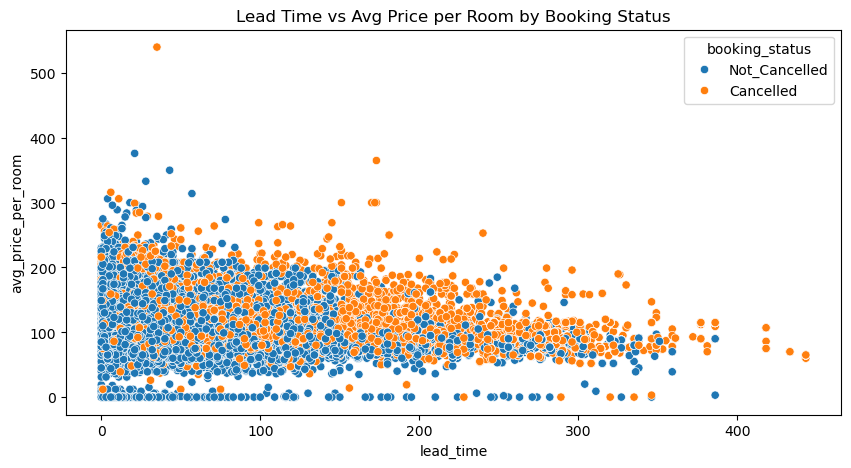

In [677]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.scatterplot(
    x='lead_time', 
    y='avg_price_per_room', 
    hue='booking_status', 
    data=df
)
plt.title("Lead Time vs Avg Price per Room by Booking Status")
plt.show()


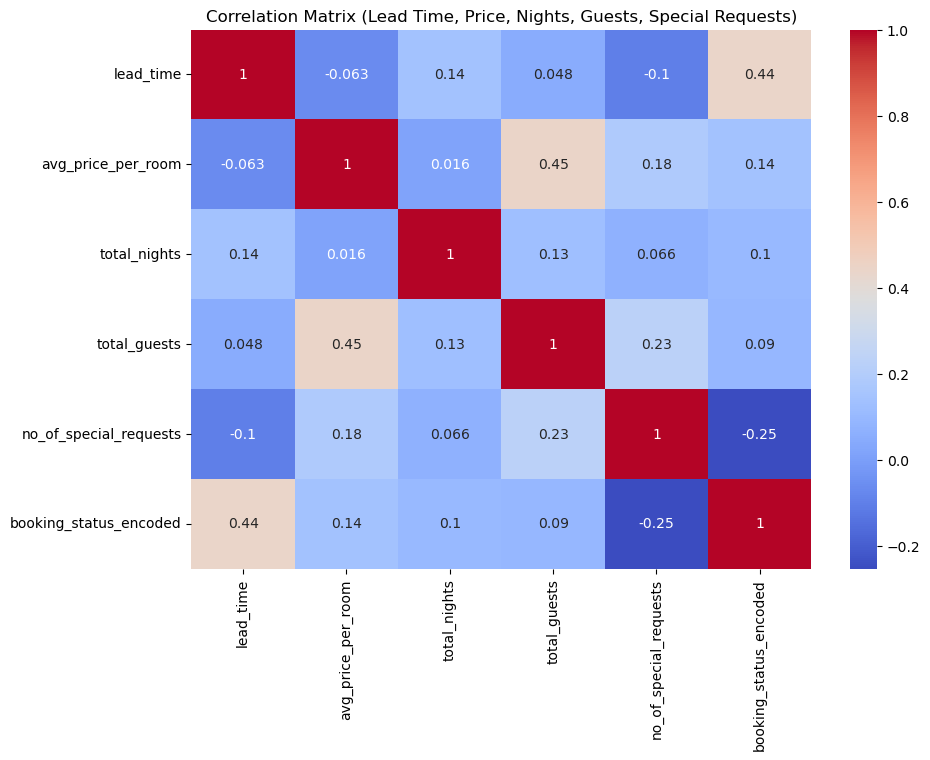

In [678]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numeric columns to check
numeric_cols = [
    'lead_time', 
    'avg_price_per_room', 
    'total_nights', 
    'total_guests', 
    'no_of_special_requests'
]

# Include target column
corr = df[numeric_cols + ['booking_status_encoded']].corr()

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Lead Time, Price, Nights, Guests, Special Requests)")
plt.show()


In [679]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Features and target
X = df[['lead_time','avg_price_per_room','total_nights','total_guests','no_of_special_requests']]
y = df['booking_status_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


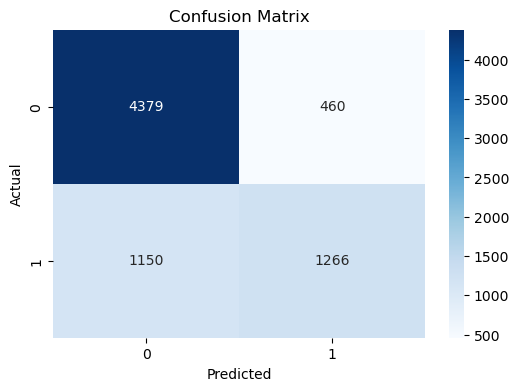

In [680]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
